# India Startup Funding — End-to-End Analysis

**Dataset:** `startup_funding.csv` (Indian startup funding rounds, ~2015–2020)  
**Goal:** Clean messy public funding data, then answer **10 high-value questions** a founder, investor, or analyst would actually ask.

| # | Analysis |
|---|----------|
| 1 | Data quality, missingness, and cleaning |
| 2 | Funding and deal volume over time |
| 3 | Where capital concentrates (cities) |
| 4 | Which sectors raise the most |
| 5 | Stage mix (Seed vs PE vs Series) |
| 6 | Deal-size distribution (median vs mega-rounds) |
| 7 | Top funded startups |
| 8 | Most active investors |
| 9 | City × industry heatmap |
| 10 | Executive insights and decision takeaways |

Run all cells from top to bottom. Charts use matplotlib/seaborn; Plotly is used where hover helps.

## 0. Setup

In [1]:
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

DATA = Path("startup_funding.csv")
df_raw = pd.read_csv(DATA, encoding="utf-8", encoding_errors="replace")
df_raw.head()

,Sr No,Date dd/mm/yyyy,Startup Name,Industry Vertical,SubVertical,City Location,Investors Name,InvestmentnType,Amount in USD,Remarks
0,1,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000",NaN
1,2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394",NaN
2,3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860",NaN
3,4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000",NaN
4,5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000",NaN


## Analysis 1 — Data quality, missingness, and cleaning

The file is a classic “real world” funding dump: Indian-style commas in amounts, mixed city spellings (Bangalore/Bengaluru), broken dates, and ~30% undisclosed cheques. We cannot rank startups on dollar totals until those are fixed.

Shape: (3044, 10)

Columns: ['Sr No', 'Date dd/mm/yyyy', 'Startup Name', 'Industry Vertical', 'SubVertical', 'City  Location', 'Investors Name', 'InvestmentnType', 'Amount in USD', 'Remarks']

Dtypes:
 Sr No                 int64
Date dd/mm/yyyy      object
Startup Name         object
Industry Vertical    object
SubVertical          object
City  Location       object
Investors Name       object
InvestmentnType      object
Amount in USD        object
Remarks              object
dtype: object

Missing values:
 Sr No                   0
Date dd/mm/yyyy         0
Startup Name            0
Industry Vertical     171
SubVertical           936
City  Location        180
Investors Name         24
InvestmentnType         4
Amount in USD         960
Remarks              2625
dtype: int64


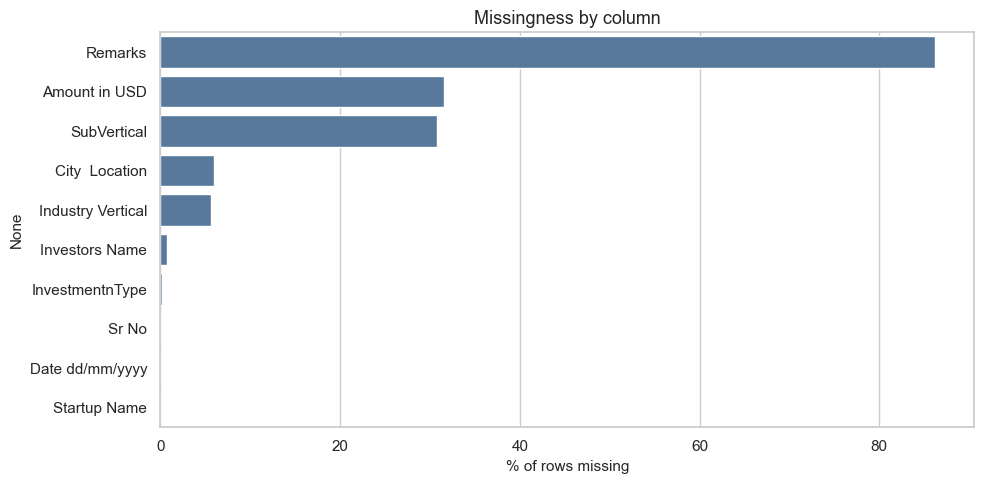

In [2]:
print("Shape:", df_raw.shape)
print("\nColumns:", list(df_raw.columns))
print("\nDtypes:\n", df_raw.dtypes)
print("\nMissing values:\n", df_raw.isna().sum())
missing_pct = (df_raw.isna().mean() * 100).sort_values(ascending=False)
fig, ax = plt.subplots()
sns.barplot(x=missing_pct.values, y=missing_pct.index, ax=ax, color="#4C78A8")
ax.set_xlabel("% of rows missing")
ax.set_title("Missingness by column")
plt.tight_layout()
plt.show()

In [3]:
CITY_MAP = {
    "bangalore": "Bengaluru", "bengaluru": "Bengaluru",
    "gurgaon": "Gurugram", "gurugram": "Gurugram",
    "new delhi": "New Delhi", "delhi": "New Delhi", "nw delhi": "New Delhi",
    "mumbai": "Mumbai", "pune": "Pune", "hyderabad": "Hyderabad",
    "chennai": "Chennai", "noida": "Noida", "ahmedabad": "Ahmedabad",
    "jaipur": "Jaipur", "kolkata": "Kolkata",
}

INDUSTRY_MAP = {
    "consumer internet": "Consumer Internet", "technology": "Technology",
    "ecommerce": "E-Commerce", "e-commerce": "E-Commerce", "e commerce": "E-Commerce",
    "healthcare": "Healthcare", "health and wellness": "Healthcare",
    "finance": "FinTech", "fintech": "FinTech", "fin-tech": "FinTech",
    "logistics": "Logistics", "logistics tech": "Logistics",
    "education": "EdTech", "ed-tech": "EdTech", "edtech": "EdTech", "e-tech": "EdTech",
    "online education platform": "EdTech",
    "food & beverage": "Food & Beverage", "food and beverage": "Food & Beverage",
    "hospitality": "Hospitality", "transportation": "Transportation", "transport": "Transportation",
    "saas": "SaaS / Software", "software": "SaaS / Software", "it": "SaaS / Software",
}


def clean_text(value):
    if pd.isna(value):
        return None
    text = str(value).replace(r"\xc2\xa0", " ").replace("\xa0", " ")
    text = re.sub(r"\\x[0-9a-fA-F]{2}", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    if not text or text.lower() in {"nan", "n/a", "na", "none"}:
        return None
    return text


def parse_date(value):
    text = clean_text(value)
    if not text:
        return pd.NaT
    text = text.replace(".", "/").replace("//", "/")
    text = re.sub(r"(\d{2})/(\d{2})(\d{4})", r"\1/\2/\3", text)
    if text == "01/07/015":
        text = "01/07/2015"
    return pd.to_datetime(text, dayfirst=True, errors="coerce")


def parse_amount(value):
    text = clean_text(value)
    if not text:
        return np.nan
    if text.lower().replace(" ", "") in {"undisclosed", "unknown", "n/a", "na"}:
        return np.nan
    text = re.sub(r"[^0-9.]", "", text.replace("+", "").replace(",", ""))
    return float(text) if text else np.nan


def normalize_city(value):
    text = clean_text(value)
    if not text:
        return "Unknown"
    key = re.sub(r"[^a-z ]", "", text.lower().split("/")[0]).strip()
    return CITY_MAP.get(key, text.split("/")[0].strip().title())


def normalize_industry(value):
    text = clean_text(value)
    if not text:
        return "Unknown"
    key = re.sub(r"[^a-z0-9 &-]", "", text.lower()).strip()
    return INDUSTRY_MAP.get(key, text.title())


def normalize_stage(value):
    text = clean_text(value)
    if not text:
        return "Unknown"
    key = re.sub(r"[^a-z0-9 /+-]", " ", text.lower().replace("\\n", " "))
    key = re.sub(r"\s+", " ", key).strip()
    rules = [
        ("debt", "Debt"), ("pre-series a", "Pre-Series A"), ("pre series a", "Pre-Series A"),
        ("series h", "Series H+"), ("series g", "Series G"), ("series f", "Series F"),
        ("series e", "Series E"), ("series d", "Series D"), ("series c", "Series C"),
        ("series b", "Series B"), ("series a", "Series A"), ("private equity", "Private Equity"),
        ("seed", "Seed"), ("angel", "Angel"), ("venture", "Venture"), ("bridge", "Bridge"),
    ]
    if "angel" in key and "seed" in key:
        return "Seed / Angel"
    for needle, label in rules:
        if needle in key:
            return label
    return "Other"


df = df_raw.copy()
df.columns = ["sr_no", "raw_date", "startup", "industry_raw", "subvertical",
              "city_raw", "investors_raw", "stage_raw", "amount_raw", "remarks"]
df["startup"] = df["startup"].map(clean_text)
df.loc[df["startup"].str.startswith("http", na=False), "startup"] = "WealthBucket"
df["date"] = df["raw_date"].map(parse_date)
df["year"] = df["date"].dt.year.astype("Int64")
df["month"] = df["date"].dt.month.astype("Int64")
df["amount_usd"] = df["amount_raw"].map(parse_amount)
df["city"] = df["city_raw"].map(normalize_city)
df["industry"] = df["industry_raw"].map(normalize_industry)
df["stage"] = df["stage_raw"].map(normalize_stage)
df["has_amount"] = df["amount_usd"].notna()
disclosed = df[df["has_amount"]].copy()

print("Rows:", len(df), "| unique startups:", df["startup"].nunique())
print("Parseable dates:", df["date"].notna().sum(), "| disclosed amounts:", df["has_amount"].sum())
print("Total disclosed USD: ${:,.0f}".format(disclosed["amount_usd"].sum()))
df[["date", "startup", "city", "industry", "stage", "amount_usd"]].head(8)

Rows: 3044 | unique startups: 2459
Parseable dates: 3043 | disclosed amounts: 2073
Total disclosed USD: $38,143,914,864


,date,startup,city,industry,stage,amount_usd
0,2020-01-09,BYJU’S,Bengaluru,EdTech,Private Equity,200000000.0
1,2020-01-13,Shuttl,Gurugram,Transportation,Series C,8048394.0
2,2020-01-09,Mamaearth,Bengaluru,E-Commerce,Series B,18358860.0
3,2020-01-02,WealthBucket,New Delhi,FinTech,Pre-Series A,3000000.0
4,2020-01-02,Fashor,Mumbai,Fashion And Apparel,Seed,1800000.0
5,2020-01-13,Pando,Chennai,Logistics,Series A,9000000.0
6,2020-01-10,Zomato,Gurugram,Hospitality,Private Equity,150000000.0
7,2019-12-12,Ecozen,Pune,Technology,Series A,6000000.0


**Finding 1.** About one in three rounds has no usable amount. Rankings below use **disclosed USD only**, while deal counts use every row. Dates cover **2015–early 2020**.

## Analysis 2 — Funding and deal volume over time

Did the Indian market get *busier* or just *bigger cheques*? Yearly deal count and yearly dollars can move in opposite directions.

,year,deals,funding,median_deal
0,2015,935,8.672422e+09,1500000.0
1,2016,993,3.828089e+09,1000000.0
2,2017,687,1.042931e+10,2250000.0
3,2018,310,5.122368e+09,4000000.0
4,2019,111,9.700919e+09,12000000.0
5,2020,7,3.902073e+08,9000000.0


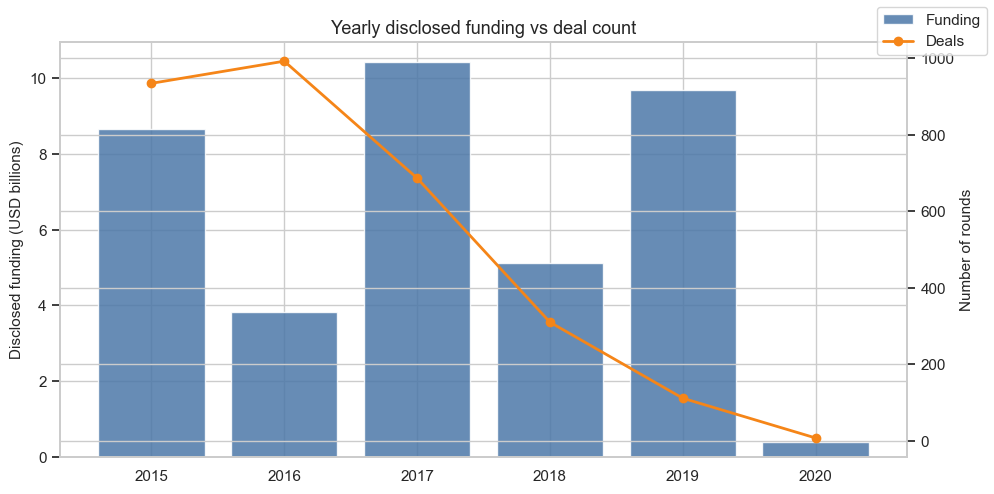

In [4]:
yearly = (
    df.dropna(subset=["year"])
    .groupby("year")
    .agg(deals=("startup", "size"), funding=("amount_usd", "sum"), median_deal=("amount_usd", "median"))
    .reset_index()
)
display(yearly)

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.bar(yearly["year"].astype(int), yearly["funding"] / 1e9, color="#4C78A8", alpha=0.85, label="Funding")
ax2.plot(yearly["year"].astype(int), yearly["deals"], color="#F58518", marker="o", linewidth=2, label="Deals")
ax1.set_ylabel("Disclosed funding (USD billions)")
ax2.set_ylabel("Number of rounds")
ax1.set_title("Yearly disclosed funding vs deal count")
fig.legend(loc="upper right")
plt.tight_layout()
plt.show()

**Finding 2.** **2016 is the volume peak** (~1,000 rounds). Later years have fewer deals but still large dollars — the market shifted from many seed cheques toward fewer, larger later-stage rounds. **2020 is incomplete** (only January in this file), so do not treat it as a crash year.

## Analysis 3 — Where capital concentrates (cities)

Startup ecosystems are geographically lumpy. We merge Bangalore/Bengaluru and Gurgaon/Gurugram so the map is not split by spelling.

,funding,deals,median
city,,,
Bengaluru,"$18,529,908,863",591,"$2,300,000"
Mumbai,"$4,958,575,015",407,"$2,000,000"
Gurugram,"$3,878,113,658",244,"$2,500,000"
New Delhi,"$3,369,171,515",270,"$1,000,000"
Noida,"$1,283,164,000",57,"$1,000,000"
Unknown,"$1,271,863,868",135,"$1,500,000"
Chennai,"$718,767,000",75,"$2,500,000"
Pune,"$717,582,000",77,"$2,000,000"
Menlo Park,"$450,000,000",1,"$450,000,000"


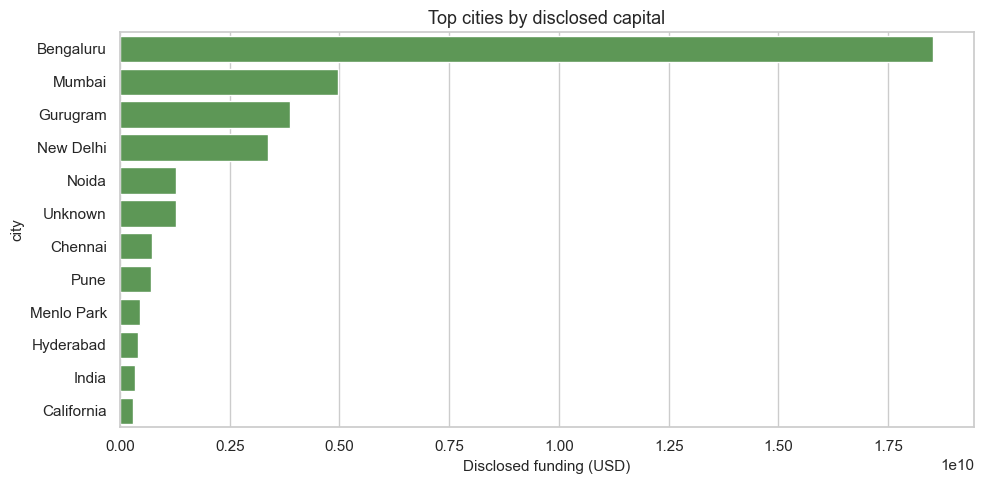

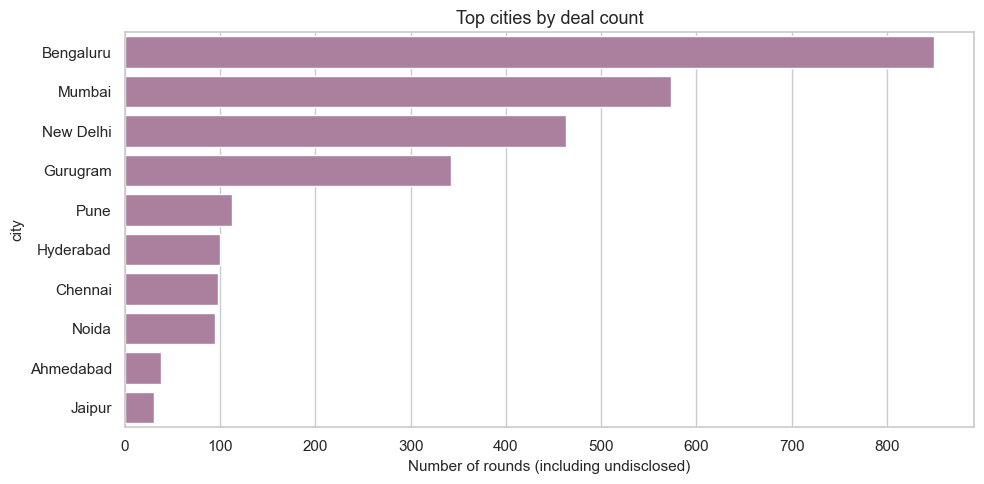

In [5]:
city_stats = (
    disclosed.groupby("city")
    .agg(funding=("amount_usd", "sum"), deals=("startup", "size"), median=("amount_usd", "median"))
    .sort_values("funding", ascending=False)
    .head(12)
)
display(city_stats.style.format({"funding": "${:,.0f}", "median": "${:,.0f}"}))

fig, ax = plt.subplots()
sns.barplot(data=city_stats.reset_index(), y="city", x="funding", ax=ax, color="#54A24B")
ax.set_xlabel("Disclosed funding (USD)")
ax.set_title("Top cities by disclosed capital")
plt.tight_layout()
plt.show()

deal_cities = df[df["city"] != "Unknown"]["city"].value_counts().head(10)
fig, ax = plt.subplots()
sns.barplot(x=deal_cities.values, y=deal_cities.index, ax=ax, color="#B279A2")
ax.set_xlabel("Number of rounds (including undisclosed)")
ax.set_title("Top cities by deal count")
plt.tight_layout()
plt.show()

**Finding 3.** **Bengaluru, Mumbai, New Delhi, and Gurugram** form the funding core. Bengaluru leads both deals and dollars. Secondary metros (Pune, Hyderabad, Chennai, Noida) show up in volume more than in mega-round dollars.

## Analysis 4 — Which sectors raise the most

Raw industry labels are extremely fragmented (800+ values). We collapse obvious aliases (eCommerce/E-Commerce, FinTech/Finance, Ed-Tech/Education) so sector comparisons are meaningful.

,funding,deals,median
industry,,,
E-Commerce,"$8,260,735,693",205,"$3,000,000"
Consumer Internet,"$6,254,084,245",590,"$1,000,000"
Transportation,"$4,068,632,394",7,"$5,000,000"
FinTech,"$3,336,349,265",73,"$6,240,000"
Technology,"$2,229,707,930",310,"$1,500,000"
Unknown,"$1,231,811,368",131,"$1,500,000"
Healthcare,"$908,904,000",51,"$3,100,000"
EdTech,"$711,639,065",41,"$2,000,000"
Online Marketplace,"$700,143,000",2,"$350,071,500"


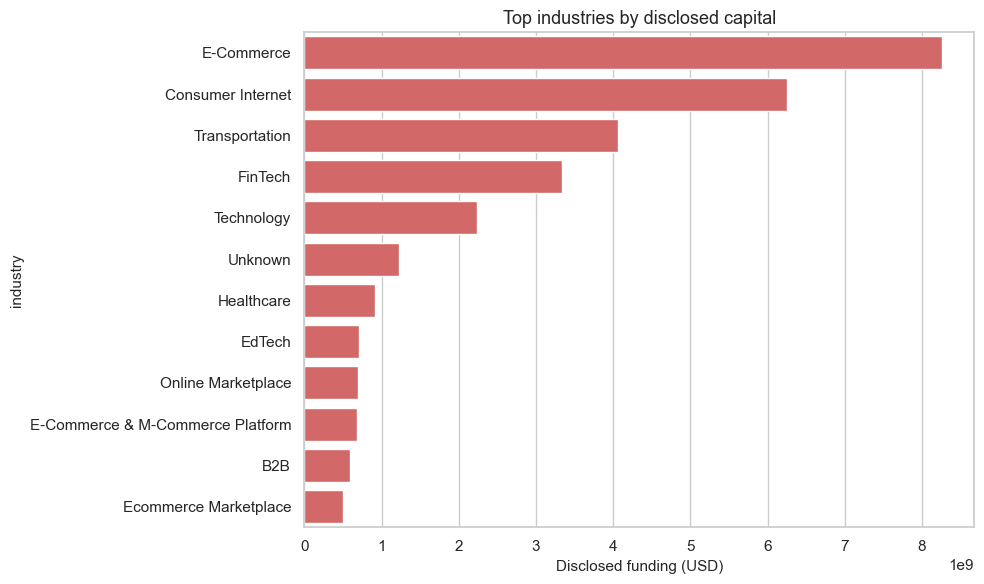

In [6]:
ind = (
    disclosed.groupby("industry")
    .agg(funding=("amount_usd", "sum"), deals=("startup", "size"), median=("amount_usd", "median"))
    .sort_values("funding", ascending=False)
    .head(12)
)
display(ind.style.format({"funding": "${:,.0f}", "median": "${:,.0f}"}))

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=ind.reset_index(), y="industry", x="funding", ax=ax, color="#E45756")
ax.set_xlabel("Disclosed funding (USD)")
ax.set_title("Top industries by disclosed capital")
plt.tight_layout()
plt.show()

**Finding 4.** **Consumer Internet** and **Technology** dominate historical labels and deal count. **E-Commerce** and **FinTech** punch above their weight in dollars because of marketplace and payments mega-rounds. A long tail of one-off verticals remains even after cleaning.

## Analysis 5 — Stage mix (Seed vs Private Equity vs named Series)

Investment type is inconsistently coded (`Seed Funding`, `Seed/ Angel Funding`, `Private Equity`). We map them into comparable stages.

,deals,funding,median
stage,,,
Seed,1401,"$930,432,108","$330,000"
Seed / Angel,138,"$125,384,810","$713,500"
Angel,3,"$464,605","$232,302"
Pre-Series A,9,"$44,372,000","$2,750,000"
Series A,24,"$203,200,000","$4,250,000"
Series B,21,"$4,805,195,735","$15,800,000"
Series C,14,"$1,044,718,394","$50,000,000"
Series D,12,"$1,481,799,000","$65,000,000"
Series E,2,"$33,000,000","$16,500,000"


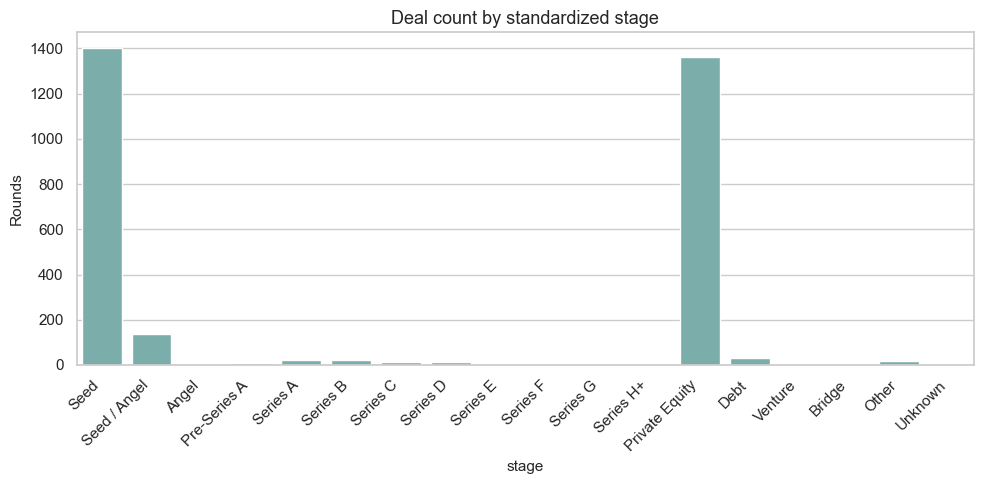

In [7]:
stage_order = ["Seed", "Seed / Angel", "Angel", "Pre-Series A", "Series A", "Series B",
               "Series C", "Series D", "Series E", "Series F", "Series G", "Series H+",
               "Private Equity", "Debt", "Venture", "Bridge", "Other", "Unknown"]
stage_stats = (
    df.groupby("stage")
    .agg(deals=("startup", "size"), funding=("amount_usd", "sum"), median=("amount_usd", "median"))
    .reindex([s for s in stage_order if s in set(df["stage"])])
)
display(stage_stats.style.format({"funding": "${:,.0f}", "median": "${:,.0f}"}))

fig, ax = plt.subplots()
sns.barplot(x=stage_stats.index, y=stage_stats["deals"], ax=ax, color="#72B7B2")
ax.set_ylabel("Rounds")
ax.set_title("Deal count by standardized stage")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Finding 5.** Most historical rows are tagged **Seed** or **Private Equity** — a coarse 2015–16 labelling habit. Named **Series A–C** become more common later. **Debt** is rare but large when it appears (NBFC / working-capital deals).

## Analysis 6 — Deal-size distribution (median vs mega-rounds)

Averages lie in venture data. A few Flipkart/Paytm-scale cheques dominate the mean.

Disclosed rounds: 2073
Mean ticket:   $18,400,345
Median ticket: $1,750,000
90th pct:      $27,959,800
99th pct:      $236,320,000


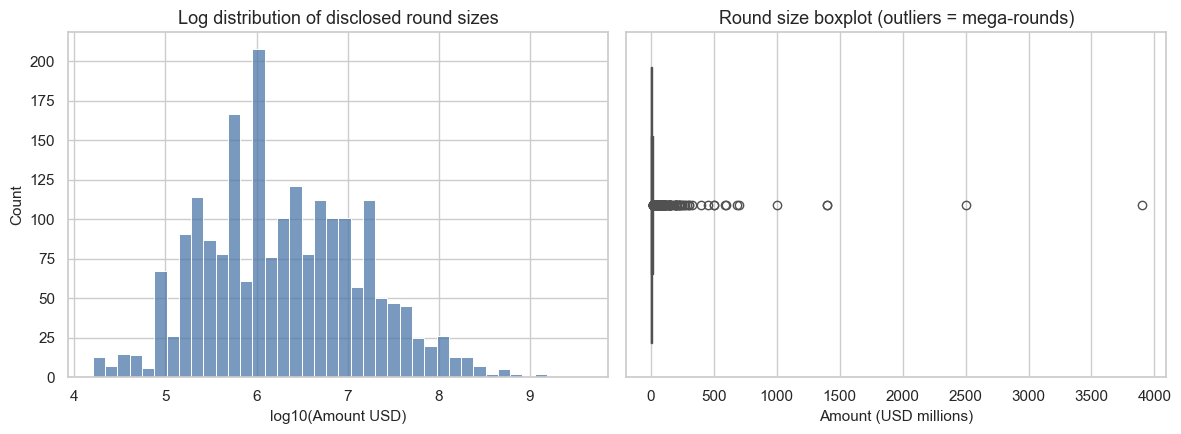

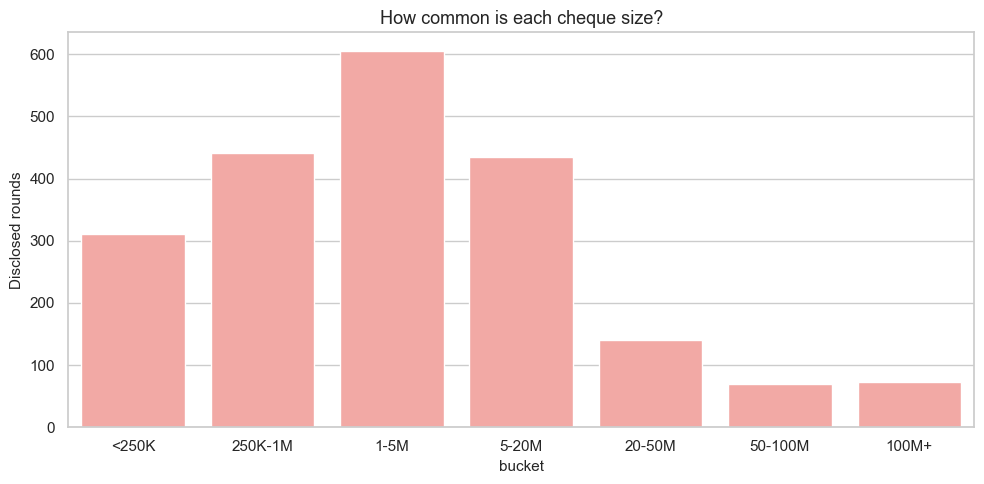

In [8]:
print("Disclosed rounds:", len(disclosed))
print("Mean ticket:   ${:,.0f}".format(disclosed["amount_usd"].mean()))
print("Median ticket: ${:,.0f}".format(disclosed["amount_usd"].median()))
print("90th pct:      ${:,.0f}".format(disclosed["amount_usd"].quantile(0.90)))
print("99th pct:      ${:,.0f}".format(disclosed["amount_usd"].quantile(0.99)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(np.log10(disclosed["amount_usd"]), bins=40, ax=axes[0], color="#4C78A8")
axes[0].set_xlabel("log10(Amount USD)")
axes[0].set_title("Log distribution of disclosed round sizes")
sns.boxplot(x=disclosed["amount_usd"] / 1e6, ax=axes[1], color="#F58518")
axes[1].set_xlabel("Amount (USD millions)")
axes[1].set_title("Round size boxplot (outliers = mega-rounds)")
plt.tight_layout()
plt.show()

bins = [0, 250_000, 1_000_000, 5_000_000, 20_000_000, 50_000_000, 100_000_000, np.inf]
labels = ["<250K", "250K-1M", "1-5M", "5-20M", "20-50M", "50-100M", "100M+"]
disclosed["bucket"] = pd.cut(disclosed["amount_usd"], bins=bins, labels=labels, right=False)
bucket_counts = disclosed["bucket"].value_counts().reindex(labels)
fig, ax = plt.subplots()
sns.barplot(x=bucket_counts.index, y=bucket_counts.values, ax=ax, color="#FF9D98")
ax.set_ylabel("Disclosed rounds")
ax.set_title("How common is each cheque size?")
plt.tight_layout()
plt.show()

**Finding 6.** The **median disclosed round is far below the mean**. Most cheques sit in the **sub-$5M** band; **$100M+** rounds are rare but they dominate headline “total funding” numbers. Use medians when describing a “typical” raise.

## Analysis 7 — Top funded startups

Which companies absorbed the most disclosed capital across all rounds in this file?

,funding,rounds,industry,city,last_round
startup,,,,,
Flipkart,"$4,059,700,000",5,E-Commerce,Bengaluru,2017-08-11 00:00:00
Rapido Bike Taxi,"$3,900,000,000",1,Transportation,Bengaluru,2019-08-27 00:00:00
Paytm,"$3,148,950,000",5,FinTech,Noida,2019-11-25 00:00:00
Ola,"$984,500,000",4,Consumer Internet,Bengaluru,2017-06-14 00:00:00
Udaan,"$870,000,000",4,B2B,Bengaluru,2019-10-02 00:00:00
Flipkart.com,"$700,000,000",1,Online Marketplace,Bengaluru,2015-07-28 00:00:00
Snapdeal,"$700,000,000",2,E-Commerce,New Delhi,2016-02-15 00:00:00
Ola Cabs,"$669,700,000",7,Transportation,Kormangala,2019-07-03 00:00:00
True North,"$600,000,000",1,FinTech,Mumbai,2018-08-30 00:00:00



Sanity check — disclosed rounds above $1B (often data-entry errors in public dumps):


,date,startup,amount_usd,city,investors_raw
60,2019-08-27 00:00:00,Rapido Bike Taxi,"$3,900,000,000",Bengaluru,Westbridge Capital
651,2017-08-11 00:00:00,Flipkart,"$2,500,000,000",Bengaluru,Softbank
830,2017-05-18 00:00:00,Paytm,"$1,400,000,000",Bengaluru,SoftBank Group
966,2017-03-21 00:00:00,Flipkart,"$1,400,000,000",Bengaluru,"Microsoft, eBay, Tencent Holdings"
31,2019-11-25 00:00:00,Paytm,"$1,000,000,000",Noida,Vijay Shekhar Sharma


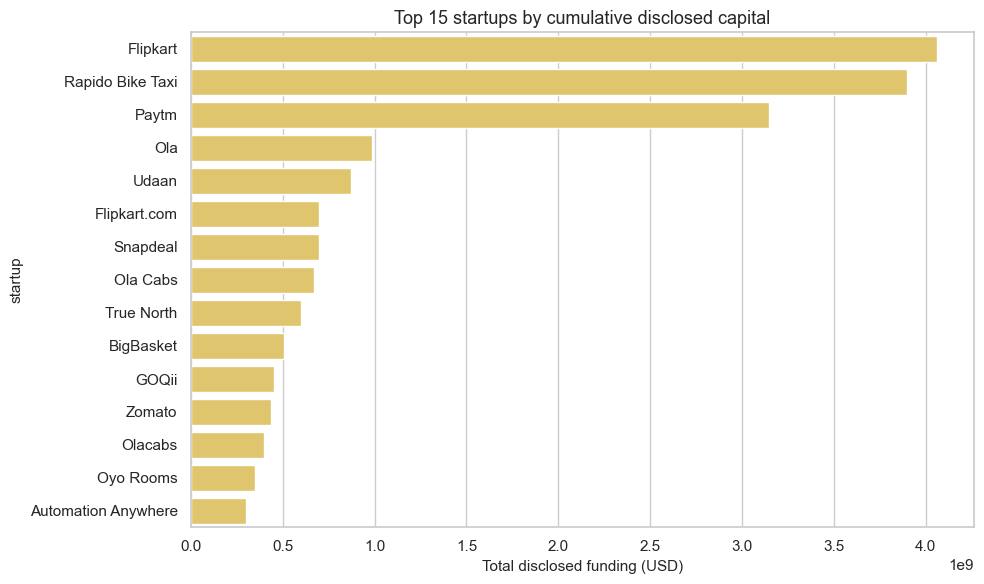

In [9]:
top_co = (
    disclosed.groupby("startup")
    .agg(funding=("amount_usd", "sum"), rounds=("sr_no", "size"),
         industry=("industry", "first"), city=("city", "first"), last_round=("date", "max"))
    .sort_values("funding", ascending=False)
    .head(15)
)
display(top_co.style.format({"funding": "${:,.0f}"}))
print("\nSanity check — disclosed rounds above $1B (often data-entry errors in public dumps):")
display(disclosed.loc[disclosed["amount_usd"] >= 1_000_000_000,
                      ["date", "startup", "amount_usd", "city", "investors_raw"]]
        .sort_values("amount_usd", ascending=False)
        .style.format({"amount_usd": "${:,.0f}"}))

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=top_co.reset_index(), y="startup", x="funding", ax=ax, color="#F2CF5B")
ax.set_xlabel("Total disclosed funding (USD)")
ax.set_title("Top 15 startups by cumulative disclosed capital")
plt.tight_layout()
plt.show()

**Finding 7.** Capital is **winner-take-most**. Flipkart and Paytm dominate legitimate mega-rounds. **Rapido Bike Taxi at $3.9B is almost certainly a data error** in the public dump (treat it as a suspect row, not a true ranking). Repeat raisers inflate cumulative totals versus one-shot seed companies.

## Analysis 8 — Most active investors

Investor cells often list syndicates (`Sequoia, Accel`). We split on commas / “and” and count appearances.

,deals,funding,unique_cos
investor,,,
Others,126,"$1,261,134,000",120
Accel Partners,81,"$1,463,369,976",68
Sequoia Capital,76,"$2,000,630,000",60
others,60,"$270,986,000",60
Blume Ventures,59,"$208,012,000",50
Kalaari Capital,58,"$896,870,000",52
SAIF Partners,53,"$708,050,000",37
Indian Angel Network,43,"$18,232,000",42
Nexus Venture Partners,32,"$471,030,200",28


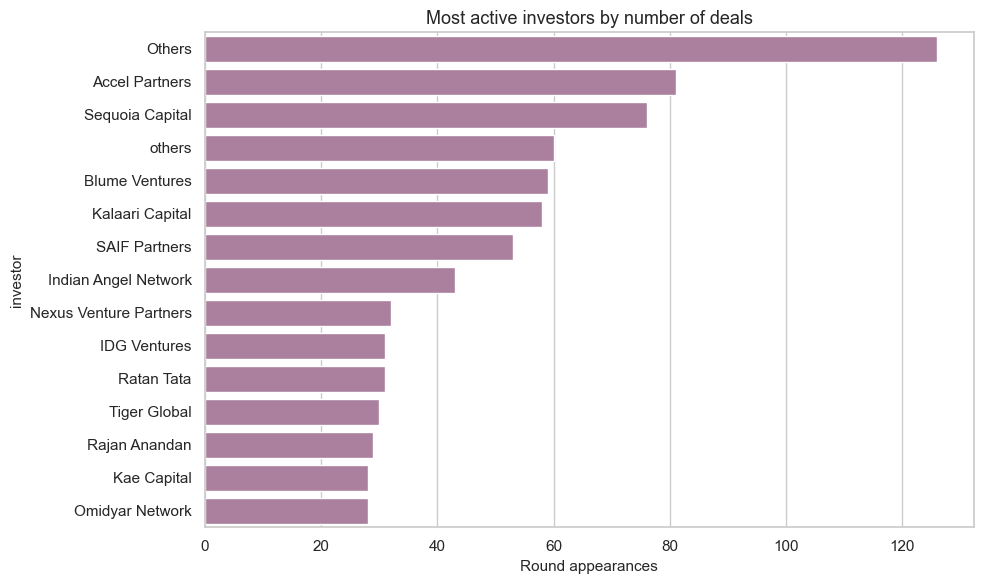

In [10]:
def split_investors(value):
    text = clean_text(value)
    if not text:
        return []
    parts = re.split(r",|&| and ", text, flags=re.IGNORECASE)
    out = []
    for part in parts:
        name = part.strip(" .")
        if name and name.lower() not in {"undisclosed", "undisclosed investors", "n/a"}:
            out.append(name)
    return out

rows = []
for _, r in df.iterrows():
    for name in split_investors(r["investors_raw"]):
        rows.append({"investor": name, "amount": r["amount_usd"], "startup": r["startup"]})
inv = pd.DataFrame(rows)
top_inv = (
    inv.groupby("investor")
    .agg(deals=("startup", "size"), funding=("amount", "sum"), unique_cos=("startup", "nunique"))
    .sort_values("deals", ascending=False)
    .head(15)
)
display(top_inv.style.format({"funding": "${:,.0f}"}))

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=top_inv.reset_index(), y="investor", x="deals", ax=ax, color="#B279A2")
ax.set_xlabel("Round appearances")
ax.set_title("Most active investors by number of deals")
plt.tight_layout()
plt.show()

**Finding 8.** Activity leaders are Indian angels/networks and frequent seed co-investors, not only global mega-funds. **Tiger Global / Sequoia / SoftBank** show up less often but on larger cheques — frequency ≠ cheque size.

## Analysis 9 — City × industry heatmap

Which city-sector clusters actually get paid? We cross the top cities with the top industries on disclosed dollars.

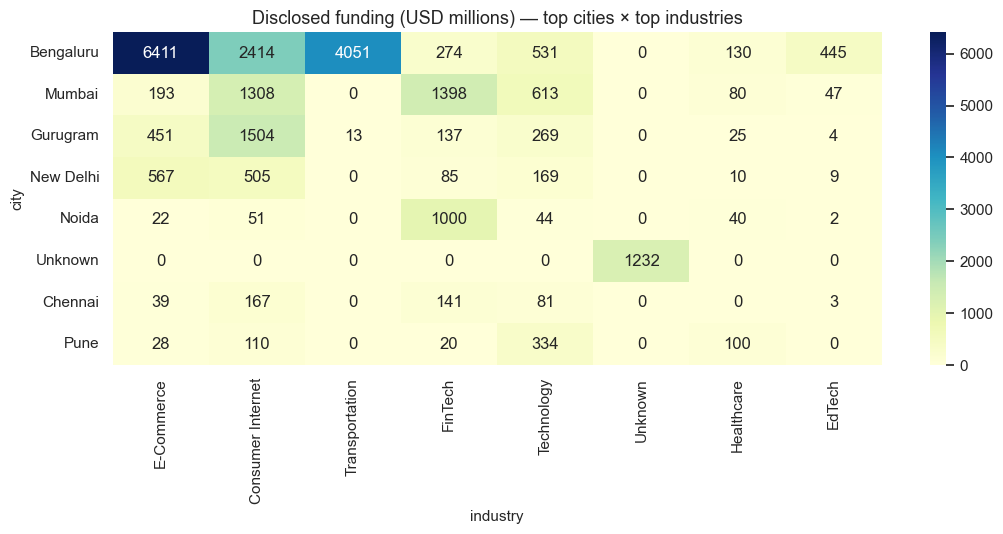

In [11]:
top_cities = city_stats.head(8).index.tolist()
top_inds = ind.head(8).index.tolist()
heat = (
    disclosed[disclosed["city"].isin(top_cities) & disclosed["industry"].isin(top_inds)]
    .pivot_table(index="city", columns="industry", values="amount_usd", aggfunc="sum", fill_value=0)
    .reindex(index=top_cities, columns=top_inds)
)
fig, ax = plt.subplots(figsize=(11, 5.5))
sns.heatmap(heat / 1e6, cmap="YlGnBu", annot=True, fmt=".0f", ax=ax)
ax.set_title("Disclosed funding (USD millions) — top cities × top industries")
plt.tight_layout()
plt.show()

**Finding 9.** Bengaluru is broad-based (internet, tech, commerce). Gurugram/New Delhi show strength in consumer internet. Mumbai is more mixed with finance-adjacent capital. Cluster density beats “spray and pray” geography.

## Analysis 10 — Executive insights and decision takeaways

We close with mega-deals, year-over-year change, and a short brief you could paste into a memo.

In [12]:
mega = disclosed.nlargest(10, "amount_usd")[
    ["date", "startup", "industry", "city", "stage", "amount_usd", "investors_raw"]
]
display(mega.style.format({"amount_usd": "${:,.0f}"}))

yoy = yearly.copy()
yoy["funding_yoy_pct"] = yoy["funding"].pct_change() * 100
yoy["deals_yoy_pct"] = yoy["deals"].pct_change() * 100
display(yoy.style.format({"funding": "${:,.0f}", "median_deal": "${:,.0f}",
                          "funding_yoy_pct": "{:.1f}%", "deals_yoy_pct": "{:.1f}%"}))

print("\n=== EXECUTIVE BRIEF ===")
print(f"Universe: {len(df):,} rounds, {df['startup'].nunique():,} startups, {df['has_amount'].mean():.0%} disclosed amounts.")
print(f"Disclosed capital: ${disclosed['amount_usd'].sum():,.0f} | median ticket ${disclosed['amount_usd'].median():,.0f} | mean ${disclosed['amount_usd'].mean():,.0f}.")
print("Time shape: deal volume peaks 2016; later years fewer rounds, heavier cheques.")
print("Geography: Bengaluru + Mumbai + NCR (New Delhi/Gurugram) is the core market.")
print("Sectors: Consumer Internet/Technology by count; E-Commerce/FinTech by dollars.")
print("Method note: 2020 is January-only; undisclosed rounds are excluded from dollar totals.")

,date,startup,industry,city,stage,amount_usd,investors_raw
60,2019-08-27 00:00:00,Rapido Bike Taxi,Transportation,Bengaluru,Series B,"$3,900,000,000",Westbridge Capital
651,2017-08-11 00:00:00,Flipkart,E-Commerce,Bengaluru,Private Equity,"$2,500,000,000",Softbank
830,2017-05-18 00:00:00,Paytm,E-Commerce,Bengaluru,Private Equity,"$1,400,000,000",SoftBank Group
966,2017-03-21 00:00:00,Flipkart,E-Commerce,Bengaluru,Private Equity,"$1,400,000,000","Microsoft, eBay, Tencent Holdings"
31,2019-11-25 00:00:00,Paytm,FinTech,Noida,Other,"$1,000,000,000",Vijay Shekhar Sharma
2648,2015-07-28 00:00:00,Flipkart.com,Online Marketplace,Bengaluru,Private Equity,"$700,000,000",Steadview Capital and existing investors
2459,2015-09-29 00:00:00,Paytm,E-Commerce & M-Commerce Platform,New Delhi,Private Equity,"$680,000,000","Alibaba Group, Ant Financial"
188,2018-08-30 00:00:00,True North,FinTech,Mumbai,Private Equity,"$600,000,000",nan
33,2019-10-02 00:00:00,Udaan,B2B,Bengaluru,Series D,"$585,000,000","Altimeter Capital, DST Global"
2244,2015-11-18 00:00:00,Ola,Car Aggregator & Retail Mobile App,Bengaluru,Private Equity,"$500,000,000","Baillie Gifford, Falcon Edge Capital, Tiger Global, SoftBank Group, DST Global, Didi Kuaidi"


,year,deals,funding,median_deal,funding_yoy_pct,deals_yoy_pct
0,2015,935,"$8,672,422,368","$1,500,000",nan%,nan%
1,2016,993,"$3,828,088,608","$1,000,000",-55.9%,6.2%
2,2017,687,"$10,429,309,730","$2,250,000",172.4%,-30.8%
3,2018,310,"$5,122,368,369","$4,000,000",-50.9%,-54.9%
4,2019,111,"$9,700,918,535","$12,000,000",89.4%,-64.2%
5,2020,7,"$390,207,254","$9,000,000",-96.0%,-93.7%



=== EXECUTIVE BRIEF ===
Universe: 3,044 rounds, 2,459 startups, 68% disclosed amounts.
Disclosed capital: $38,143,914,864 | median ticket $1,750,000 | mean $18,400,345.
Time shape: deal volume peaks 2016; later years fewer rounds, heavier cheques.
Geography: Bengaluru + Mumbai + NCR (New Delhi/Gurugram) is the core market.
Sectors: Consumer Internet/Technology by count; E-Commerce/FinTech by dollars.
Method note: 2020 is January-only; undisclosed rounds are excluded from dollar totals.
